In [1]:
import sys
sys.path.append("..")
from dotenv import load_dotenv
load_dotenv("../.env")

import joblib
import matplotlib.pyplot as plt
from src.db import read_sql
from src.anomaly import first_alarm_cycle

bundle = joblib.load("../models/anomaly_latest.joblib")
th, ver = bundle["model"].threshold, bundle["version"]
print(ver, th)

anomaly_iforest_202610011535 0.5454723043051791


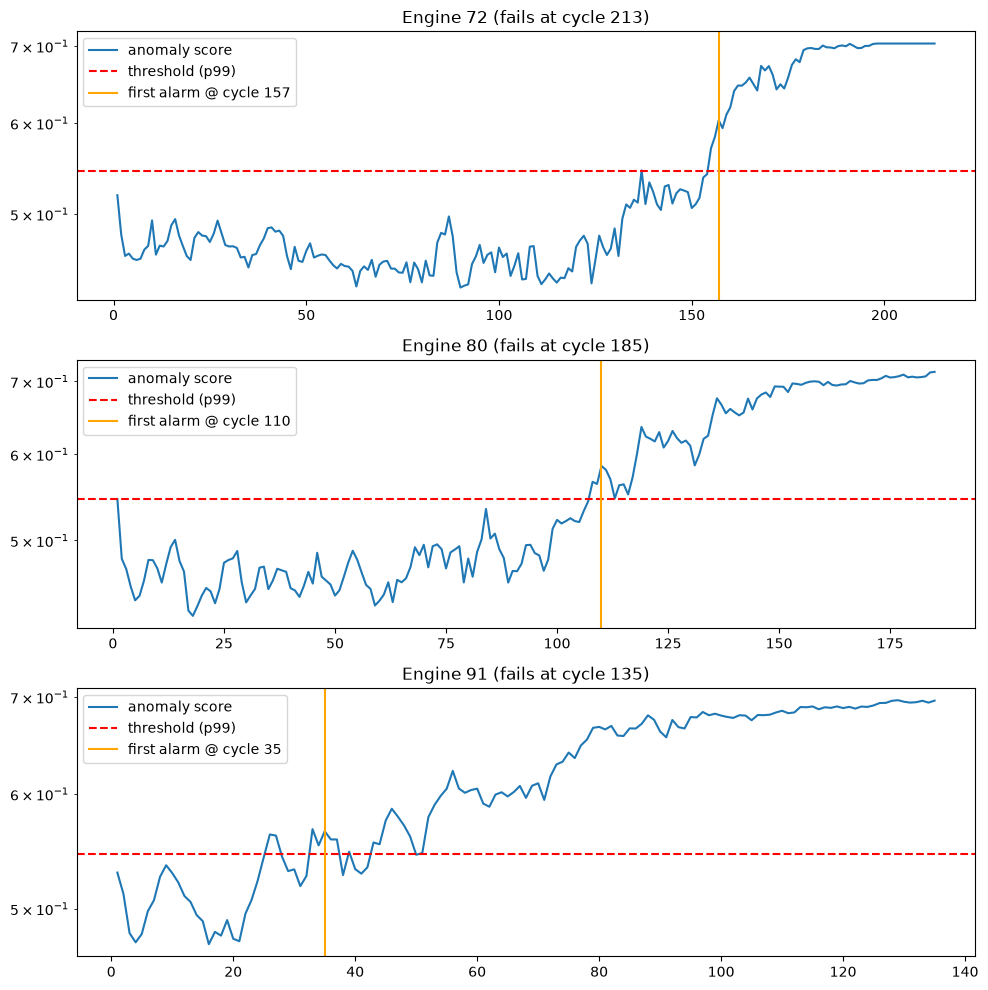

In [2]:
s = read_sql("""
    SELECT unit_id, cycle, score FROM ml.anomaly_scores
    WHERE split = 'train' AND model_version = :v AND unit_id IN (72, 80, 91)
    ORDER BY unit_id, cycle""", v=ver)

fig, axes = plt.subplots(3, 1, figsize=(10, 10))
for ax, (u, d) in zip(axes, s.groupby("unit_id")):
    ax.plot(d["cycle"], d["score"], label="anomaly score")
    ax.axhline(th, color="red", ls="--", label="threshold (p99)")
    alarm = first_alarm_cycle(d["cycle"].to_numpy(), (d["score"] > th).to_numpy())
    if alarm == alarm:   # NaN이 아니면 (경보가 울렸으면)
        ax.axvline(alarm, color="orange", label=f"first alarm @ cycle {alarm}")
    ax.set_yscale("log")
    ax.set_title(f"Engine {u} (fails at cycle {d['cycle'].max()})")
    ax.legend()
plt.tight_layout()
plt.show()